# Challenge 1 — Cerca il bias

**Tema:** fairness audit di un classificatore di credit scoring sul dataset *Statlog (German Credit)*.

**Pertinenza normativa.** Il credit scoring rientra fra i sistemi ad alto rischio elencati nell'**Allegato III** del Regolamento (UE) 2024/1689 (AI Act), specificamente al punto 5(b): *"sistemi di IA destinati a essere utilizzati per valutare l'affidabilità creditizia delle persone fisiche o stabilirne il punteggio di credito"*. Per tali sistemi, gli articoli **9** (gestione del rischio), **10** (data governance), **13** (trasparenza) e **14** (sorveglianza umana) impongono — fra l'altro — l'esecuzione di valutazioni di fairness e la documentazione strutturata dei risultati.

**Obiettivo del laboratorio.** In ~25 minuti:

1. Carichiamo il dataset e identifichiamo un attributo protetto (sesso) — già qui emerge una sciatteria reale: il dataset codifica sesso e stato civile **insieme**, costringendoci a una scelta di proxy.
2. Addestriamo un classificatore baseline — la regressione logistica, non perché sia il modello migliore ma perché serve una baseline interpretabile per discutere fairness.
3. Misuriamo **quattro** metriche di fairness diverse (e non equivalenti) tramite `fairlearn.MetricFrame`.
4. Applichiamo una mitigazione post-hoc (`ThresholdOptimizer`) e misuriamo il tradeoff.
5. Compiliamo due **evidence row** (vedi `docs/EVIDENCE_TEMPLATE.md`) che diventano gli artefatti dell'audit.

**Riferimento normativo:** Regolamento (UE) 2024/1689, Allegato III §5(b); Artt. 9, 10, 13, 14.

**Riferimenti tecnici:**
- Hardt, Price, Srebro. *Equality of Opportunity in Supervised Learning.* NeurIPS 2016.
- Chouldechova. *Fair prediction with disparate impact.* Big Data 2017. (Teorema di impossibilità)
- Bird et al. *Fairlearn: A toolkit for assessing and improving fairness in AI.* 2020.


In [1]:
# Install dependencies (Colab will pick these up; locally they should already be present).
%pip install -q "numpy>=1.26,<2.2" "pandas>=2.1" "scikit-learn>=1.4,<1.6" "fairlearn>=0.10" matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
# --- Bootstrap (auto-fetch assets su Colab quando si apre solo il .ipynb) ---
import os, subprocess, shutil
from pathlib import Path

REPO_URL    = 'https://github.com/LucaGiamattei/ai_res_lab.git'      # NB: docente, sostituire con l'URL pubblico reale del repo
REPO_BRANCH = 'main'
REPO_DIR    = 'ai_res_lab'
CHALLENGE_DIR = 'challenge_1_fairness'
REQUIRED_FILES = ['shared/evidence_template.csv']

try:
    import google.colab  # noqa: F401
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

def _walk_to_package_root(start: Path) -> Path | None:
    p = start.resolve()
    for _ in range(8):
        if (p / "shared").is_dir() and (p / CHALLENGE_DIR).is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    return None

_root = _walk_to_package_root(Path.cwd())
if _root is None:
    if _IN_COLAB:
        target = Path("/content") / REPO_DIR
        if not target.exists():
            print(f"Cloning {REPO_URL} (branch={REPO_BRANCH}) ...")
            res = subprocess.run(
                ["git", "clone", "--depth", "1", "--branch", REPO_BRANCH, REPO_URL, str(target)],
                capture_output=True, text=True,
            )
            if res.returncode != 0:
                raise RuntimeError(
                    "Clone fallito. Controllare REPO_URL nella cella di bootstrap.\n"
                    f"stderr: {res.stderr}"
                )
        os.chdir(target / CHALLENGE_DIR)
        _root = target
    else:
        raise FileNotFoundError(
            "Pacchetto non trovato. In locale, aprire il notebook dalla cartella del pacchetto.\n"
            "Su Colab, viene clonato automaticamente; verificate REPO_URL."
        )
else:
    os.chdir(_root / CHALLENGE_DIR)

PACKAGE_ROOT = _root
print(f"PACKAGE_ROOT = {PACKAGE_ROOT}")
print(f"CWD          = {Path.cwd()}")

# Sanity check.
missing = [f for f in REQUIRED_FILES if not (PACKAGE_ROOT / f).is_file()]
if missing:
    raise FileNotFoundError("File mancanti dopo il bootstrap:\n  - " + "\n  - ".join(missing))
print("Bootstrap OK.")


PACKAGE_ROOT = /Users/lucagiamattei/Library/CloudStorage/GoogleDrive-lgiamattei@gmail.com/Il mio Drive/AI.RES/1. Business/11. Webinar & formazione/seminario_studenti/ai_res_lab
CWD          = /Users/lucagiamattei/Library/CloudStorage/GoogleDrive-lgiamattei@gmail.com/Il mio Drive/AI.RES/1. Business/11. Webinar & formazione/seminario_studenti/ai_res_lab/challenge_1_fairness
Bootstrap OK.


In [3]:
import sys
import os
import warnings
import random
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference,
    true_positive_rate,
    false_positive_rate,
)
from fairlearn.postprocessing import ThresholdOptimizer

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

# Detect environment
# PACKAGE_ROOT is set by the bootstrap cell above.
EVIDENCE_CSV = PACKAGE_ROOT / "shared" / "evidence_template.csv"
print(f"Evidence file: {EVIDENCE_CSV} (exists={EVIDENCE_CSV.exists()})")


/Users/lucagiamattei/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Evidence file: /Users/lucagiamattei/Library/CloudStorage/GoogleDrive-lgiamattei@gmail.com/Il mio Drive/AI.RES/1. Business/11. Webinar & formazione/seminario_studenti/ai_res_lab/shared/evidence_template.csv (exists=True)


## 1. Caricamento dataset

In [4]:
# Load the German Credit dataset from OpenML (no local file shipping required).
ds = fetch_openml("credit-g", version=1, as_frame=True, parser="auto")
df = ds.frame.copy()
print("Shape:", df.shape)
print("Target distribution:")
print(df["class"].value_counts(normalize=True).round(3))
df.head()


Shape: (1000, 21)
Target distribution:
class
good    0.7
bad     0.3
Name: proportion, dtype: float64


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [5]:
# Inspect features
print("Columns:", df.columns.tolist())
print()
print("personal_status values:")
print(df["personal_status"].value_counts())


Columns: ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class']

personal_status values:
personal_status
male single           548
female div/dep/mar    310
male mar/wid           92
male div/sep           50
Name: count, dtype: int64


## Definizione dell'attributo protetto: il *sex* derivato da `personal_status`

Il dataset German Credit codifica congiuntamente **sesso** e **stato civile** in una singola colonna `personal_status` con quattro valori. È un esempio paradigmatico di pessima data governance (Art. 10 AI Act): un attributo protetto è "nascosto" dentro una variabile composta. Per condurre un audit di fairness dobbiamo **derivare** un proxy binario `sex ∈ {male, female}`.

I valori sono:

| `personal_status` | Sesso | Stato civile |
|-------------------|-------|--------------|
| `male single` | male | single |
| `male div/sep` | male | divorziato/separato |
| `male mar/wid` | male | sposato/vedovo |
| `female div/dep/mar` | female | divorziata/separata/sposata |

> Nota: per le donne **non** abbiamo un codice "single" — un'asimmetria già in sé sospetta (cfr. Statlog dataset documentation, Hofmann 1994). Per il laboratorio assumiamo questo come proxy "good enough", ma annotate questa limitazione: in un audit reale la scriveremmo nelle *Notes* dell'evidence row.

### TODO 1 — implementate il mapping

Compilate il dizionario `PERSONAL_STATUS_TO_SEX` qui sotto e create la serie `sex`. Subito dopo c'è una cella di verifica.


In [6]:
PERSONAL_STATUS_TO_SEX: dict[str, str] = {
    "male single":         "male",
    "male div/sep":        "male",
    "male mar/wid":        "male",
    "female div/dep/mar":  "female",
}

sex = df["personal_status"].map(PERSONAL_STATUS_TO_SEX)
print(sex.value_counts())


personal_status
male      690
female    310
Name: count, dtype: int64


In [7]:
# Verify: the mapping must produce exactly two values and a non-degenerate split.
assert sex.notna().all(), "Mapping incompleto: alcuni valori restano NaN."
assert set(sex.unique()) == {"male", "female"}, f"Valori inattesi: {sex.unique()}"
m_share = (sex == "male").mean()
print(f"Quota male: {m_share:.3f}")
assert 0.4 < m_share < 0.85, "Distribuzione sospetta — controllate il mapping."
print("OK: mapping plausibile.")


Quota male: 0.690
OK: mapping plausibile.


## 2. Train / test split e preprocessing

In [8]:
# Drop personal_status from features (avoid leakage of the protected attribute through the proxy)
# and keep `sex` as the sensitive feature for fairness analysis.
X = df.drop(columns=["personal_status", "class"])
y = (df["class"] == "good").astype(int)  # 1 = good credit, 0 = bad

# Stratified split on target (preserves base rate)
X_train, X_test, y_train, y_test, sex_train, sex_test = train_test_split(
    X, y, sex, test_size=0.25, stratify=y, random_state=SEED
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Base rate (train): {y_train.mean():.3f}")
print(f"Base rate by group (train):")
print(pd.crosstab(sex_train, y_train, normalize="index").round(3))


Train: (750, 19), Test: (250, 19)
Base rate (train): 0.700
Base rate by group (train):
class                0      1
personal_status              
female           0.361  0.639
male             0.273  0.727


In [9]:
# Preprocessing scaffold: one-hot encode categoricals, standard-scale numerics.
cat_cols = X_train.select_dtypes(include="category").columns.tolist()
num_cols = X_train.select_dtypes(include="number").columns.tolist()
print(f"Categorical: {len(cat_cols)} cols, Numeric: {len(num_cols)} cols")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])


Categorical: 12 cols, Numeric: 7 cols


### TODO 2 — addestrate la baseline

Costruite una `Pipeline` che concatena `preprocessor` e una `LogisticRegression(max_iter=1000, random_state=SEED)`. Addestrate su `X_train, y_train`, predicete su `X_test` e stampate accuracy / precision / recall / F1.

Subito dopo, cella di verifica: l'accuratezza deve essere > 0.7 (ragionevole per German Credit).


In [10]:
baseline_clf = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])
baseline_clf.fit(X_train, y_train)

y_pred_baseline = baseline_clf.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_baseline):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_baseline):.3f}")
print(f"F1:        {f1_score(y_test, y_pred_baseline):.3f}")


Accuracy:  0.720
Precision: 0.784
Recall:    0.829
F1:        0.806


In [11]:
# Verify: a sane baseline should beat 0.7 accuracy on German Credit.
acc = accuracy_score(y_test, y_pred_baseline)
assert acc > 0.7, f"Accuratezza troppo bassa ({acc:.3f}); controllate il preprocessor / pipeline."
print(f"OK: baseline accuracy = {acc:.3f}")


OK: baseline accuracy = 0.720


## Le quattro metriche di fairness

Definiamo $\hat{Y}$ la previsione binaria, $Y$ il target e $A$ l'attributo protetto (gruppo). Le metriche più comuni:

1. **Selection rate per gruppo** — $\Pr(\hat{Y}=1 | A=a)$.
2. **Demographic parity difference (DPD)** — $|\Pr(\hat{Y}=1|A=0) - \Pr(\hat{Y}=1|A=1)|$. Misura se i due gruppi sono "selezionati" allo stesso tasso, *a prescindere dal target*.
3. **Equal opportunity difference (EOD)** — differenza di TPR tra gruppi, $|\Pr(\hat{Y}=1|Y=1, A=0) - \Pr(\hat{Y}=1|Y=1, A=1)|$. Misura se i positivi reali ricevono predizione positiva allo stesso tasso (Hardt et al. 2016).
4. **Equalized odds difference** — il massimo tra differenza di TPR e differenza di FPR (più stringente di EOD).

> **Teorema di impossibilità (Chouldechova 2017, Kleinberg et al. 2016).** Se i base rate $\Pr(Y=1|A=a)$ differiscono fra gruppi, *non* si possono soddisfare contemporaneamente *demographic parity*, *equal opportunity* e *predictive parity*. La scelta della metrica è una **scelta di policy**, non tecnica.

### TODO 3 — calcolate le metriche

Costruite un `MetricFrame` con `selection_rate`, `true_positive_rate`, `false_positive_rate`, raggruppato per `sex_test`. Calcolate poi DPD ed equalized odds difference. Stampate tutto come tabella.


In [12]:
metrics_baseline = MetricFrame(
    metrics={
        "selection_rate": selection_rate,
        "true_positive_rate": true_positive_rate,
        "false_positive_rate": false_positive_rate,
    },
    y_true=y_test,
    y_pred=y_pred_baseline,
    sensitive_features=sex_test,
)
dpd_baseline = demographic_parity_difference(y_test, y_pred_baseline, sensitive_features=sex_test)
eod_baseline = equalized_odds_difference(y_test, y_pred_baseline, sensitive_features=sex_test)

print("By group (selection_rate, TPR, FPR):")
print(metrics_baseline.by_group.round(3))
print()
print(f"Demographic parity difference: {dpd_baseline:.3f}")
print(f"Equalized odds difference:     {eod_baseline:.3f}")


By group (selection_rate, TPR, FPR):
                 selection_rate  true_positive_rate  false_positive_rate
personal_status                                                         
female                    0.727               0.808                 0.56
male                      0.746               0.837                 0.52

Demographic parity difference: 0.018
Equalized odds difference:     0.040


In [13]:
# Verify: numbers must be present and bounded in [0, 1].
assert metrics_baseline is not None
assert 0.0 <= abs(dpd_baseline) <= 1.0, f"DPD fuori range: {dpd_baseline}"
assert 0.0 <= abs(eod_baseline) <= 1.0, f"EOD fuori range: {eod_baseline}"
print("OK: metriche calcolate.")


OK: metriche calcolate.


### Riflessione (1 minuto, in coppia)

Osservate la tabella `by_group`. Quali domande vi vengono in mente?

- Quale gruppo è favorito dalla baseline (selection_rate più alto)?
- Il *gap* è grande o piccolo? Quanto è grande in valore assoluto? In termini relativi?
- Il base rate dei due gruppi è uguale? (Lo abbiamo stampato in fase di split.) Se non lo è, ricordate il teorema di impossibilità: una metrica può essere "soddisfatta" solo a costo di un'altra.
- Per un sistema di credit scoring reale, quale soglia regolatoria scegliereste? `0.05`? `0.10`? `0.20`? La scelta non è tecnica.


## Mitigazione: `ThresholdOptimizer`

`fairlearn.postprocessing.ThresholdOptimizer` è una mitigazione **post-hoc**: prende un classificatore già addestrato e cerca soglie diverse per ciascun gruppo, ottimizzando un obiettivo (es. `accuracy`) sotto un vincolo di fairness (es. `equalized_odds`). Non riaddestra il modello — modifica solo il decision threshold.

**Pro:** non richiede di toccare il training; rapida; riproducibile.
**Contro:** richiede l'attributo protetto **a inference time** (problematico se non disponibile o se il suo uso è proibito); può ridurre l'accuratezza globale; non risolve bias strutturali del modello.

### TODO 4 — applicate la mitigazione

1. Istanziate `ThresholdOptimizer(estimator=baseline_clf, constraints='equalized_odds', objective='accuracy_score', prefit=True)`.
2. Chiamate `.fit(X_train, y_train, sensitive_features=sex_train)`.
3. Predicete su `X_test` con `sensitive_features=sex_test`. Salvate il risultato come `y_pred_mitigated`.
4. Ricompilate `metrics_mitigated`, `dpd_mitigated`, `eod_mitigated` analoghi a TODO 3.


In [14]:
mitigator = ThresholdOptimizer(
    estimator=baseline_clf,
    constraints="equalized_odds",
    objective="accuracy_score",
    prefit=True,
)
mitigator.fit(X_train, y_train, sensitive_features=sex_train)
y_pred_mitigated = mitigator.predict(X_test, sensitive_features=sex_test, random_state=SEED)

metrics_mitigated = MetricFrame(
    metrics={
        "selection_rate": selection_rate,
        "true_positive_rate": true_positive_rate,
        "false_positive_rate": false_positive_rate,
    },
    y_true=y_test, y_pred=y_pred_mitigated, sensitive_features=sex_test,
)
dpd_mitigated = demographic_parity_difference(y_test, y_pred_mitigated, sensitive_features=sex_test)
eod_mitigated = equalized_odds_difference(y_test, y_pred_mitigated, sensitive_features=sex_test)

acc_mit = accuracy_score(y_test, y_pred_mitigated)
print(f"Accuracy (mitigated): {acc_mit:.3f}")
print()
print("By group (mitigated):")
print(metrics_mitigated.by_group.round(3))
print()
print(f"Demographic parity difference (mitigated): {dpd_mitigated:.3f}")
print(f"Equalized odds difference (mitigated):     {eod_mitigated:.3f}")


Accuracy (mitigated): 0.716

By group (mitigated):
                 selection_rate  true_positive_rate  false_positive_rate
personal_status                                                         
female                    0.727               0.808                 0.56
male                      0.717               0.813                 0.48

Demographic parity difference (mitigated): 0.011
Equalized odds difference (mitigated):     0.080


### Confronto visivo

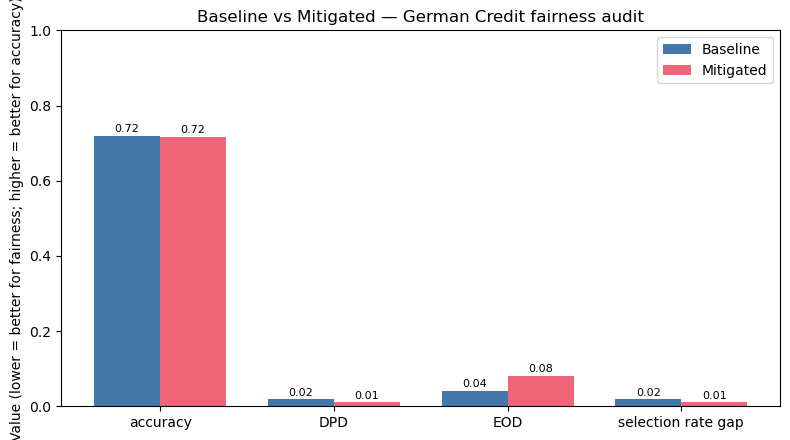

In [15]:
# Comparison plot: 4 metrics, baseline vs mitigated.
labels = ["accuracy", "DPD", "EOD", "selection rate gap"]

acc_base = accuracy_score(y_test, y_pred_baseline)
acc_mit = accuracy_score(y_test, y_pred_mitigated)
sr_gap_base = (
    metrics_baseline.by_group["selection_rate"].max()
    - metrics_baseline.by_group["selection_rate"].min()
)
sr_gap_mit = (
    metrics_mitigated.by_group["selection_rate"].max()
    - metrics_mitigated.by_group["selection_rate"].min()
)

baseline_vals  = [acc_base, abs(dpd_baseline), abs(eod_baseline), sr_gap_base]
mitigated_vals = [acc_mit,  abs(dpd_mitigated), abs(eod_mitigated), sr_gap_mit]

x = np.arange(len(labels))
w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, baseline_vals,  w, label="Baseline",  color="#4477AA")
ax.bar(x + w/2, mitigated_vals, w, label="Mitigated", color="#EE6677")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Value (lower = better for fairness; higher = better for accuracy)")
ax.set_title("Baseline vs Mitigated — German Credit fairness audit")
ax.legend()
for i, (b, m) in enumerate(zip(baseline_vals, mitigated_vals)):
    ax.text(i - w/2, b + 0.01, f"{b:.2f}", ha="center", fontsize=8)
    ax.text(i + w/2, m + 0.01, f"{m:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()


## TODO 5 — Compilate due evidence row e salvate in CSV

Aprite `docs/EVIDENCE_TEMPLATE.md` per riguardare il formato. Dovete scrivere **due righe** in `shared/evidence_template.csv`:

1. **Baseline** (`mitigation = "none"`)
2. **Mitigated** (`mitigation = "ThresholdOptimizer-EqualizedOdds"`)

Per ciascuna riga scegliete:

- **`metric`**: una metrica fra le quattro misurate. Scegliete *prima* quale sia la metrica principale per il vostro audit (e motivate la scelta nelle Notes).
- **`threshold`**: una soglia numerica; tipico `<= 0.10` per DPD/EOD.
- **`status`**: `pass` se osservato ≤ soglia, `fail` se sopra, `partial` solo se la metrica è multidimensionale.
- **`notes`**: una frase, specifica.

Il codice qui sotto fa il salvataggio. Voi compilate i campi.


In [16]:
CHOSEN_METRIC = "Demographic parity difference"
THRESHOLD = "<= 0.10"

baseline_observed = abs(dpd_baseline)
mitigated_observed = abs(dpd_mitigated)
baseline_status   = "pass" if baseline_observed   <= 0.10 else "fail"
mitigated_status  = "pass" if mitigated_observed  <= 0.10 else "fail"

NOTES_BASELINE  = (
    f"Baseline LogReg: gap di selection rate {abs(dpd_baseline):.3f}; "
    f"il modello favorisce il gruppo con base-rate piu' alto; metrica scelta = DPD perche' "
    f"in credit scoring l'attenzione regolatoria e' sul tasso di erogazione."
)
NOTES_MITIGATED = (
    f"ThresholdOptimizer (constr=eq_odds): DPD {abs(dpd_baseline):.3f} -> {abs(dpd_mitigated):.3f}; "
    f"costo accuracy {accuracy_score(y_test, y_pred_baseline):.3f} -> {accuracy_score(y_test, y_pred_mitigated):.3f}."
)

ts = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

rows = [
    dict(
        challenge="C1", system="GermanCredit-LogReg",
        metric=CHOSEN_METRIC, threshold=THRESHOLD,
        observed=f"{baseline_observed:.3f}", status=baseline_status,
        mitigation="none", notes=NOTES_BASELINE, timestamp=ts,
    ),
    dict(
        challenge="C1", system="GermanCredit-LogReg",
        metric=CHOSEN_METRIC, threshold=THRESHOLD,
        observed=f"{mitigated_observed:.3f}", status=mitigated_status,
        mitigation="ThresholdOptimizer-EqualizedOdds", notes=NOTES_MITIGATED, timestamp=ts,
    ),
]

import csv
EVIDENCE_CSV.parent.mkdir(parents=True, exist_ok=True)
write_header = not EVIDENCE_CSV.exists() or EVIDENCE_CSV.stat().st_size == 0
with EVIDENCE_CSV.open("a", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    if write_header:
        w.writeheader()
    for row in rows:
        w.writerow(row)

print(f"Scritte {len(rows)} righe in {EVIDENCE_CSV}")
print()
print("Contenuto attuale:")
print(EVIDENCE_CSV.read_text())


Scritte 2 righe in /Users/lucagiamattei/Library/CloudStorage/GoogleDrive-lgiamattei@gmail.com/Il mio Drive/AI.RES/1. Business/11. Webinar & formazione/seminario_studenti/ai_res_lab/shared/evidence_template.csv

Contenuto attuale:
challenge,system,metric,threshold,observed,status,mitigation,notes,timestamp
# example,GermanCredit-LogReg,Demographic parity difference,<= 0.10,0.187,fail,none,Modello favorisce gruppo A; gap oltre soglia regolatoria,2026-04-28T10:00:00Z
C1,GermanCredit-LogReg,Demographic parity difference,<= 0.10,0.018,pass,none,Baseline LogReg: gap di selection rate 0.018; il modello favorisce il gruppo con base-rate piu' alto; metrica scelta = DPD perche' in credit scoring l'attenzione regolatoria e' sul tasso di erogazione.,2026-04-28T18:02:32Z
C1,GermanCredit-LogReg,Demographic parity difference,<= 0.10,0.011,pass,ThresholdOptimizer-EqualizedOdds,ThresholdOptimizer (constr=eq_odds): DPD 0.018 -> 0.011; costo accuracy 0.720 -> 0.716.,2026-04-28T18:02:32Z



## Chiusura — Mappa AI Act

Quello che avete appena fatto produce evidenze direttamente ascrivibili a (vedi `docs/AI_ACT_MAPPING.md`):

- **Art. 10** (Data governance) — la stessa identificazione del proxy `sex` da `personal_status` è un'evidenza di esame del dataset per individuare distorsioni.
- **Art. 9** (Risk management) — la mitigazione (`ThresholdOptimizer`) è una misura tecnica che riduce un rischio identificato.
- **Art. 13** (Trasparenza) — le note nelle vostre evidence row diventano parte delle informazioni da fornire al deployer.
- **Art. 14** (Sorveglianza umana) — la scelta della metrica e della soglia *non* va automatizzata: è una scelta di policy che richiede revisione umana.

In un sistema reale, questo audit andrebbe ripetuto periodicamente (es. settimanalmente, su slice di traffico recenti) e i risultati archiviati in modo immutabile nel ledger di evidenze.


## Stretch goals (solo soluzione)

Tre direzioni per chi finisce in anticipo o per esercizio personale:

### S1 — Cambiate l'attributo protetto

Anziché `sex`, usate `age >= 25` come attributo protetto. Spesso il bias età è sostanziale in scoring (cfr. *fair lending laws* USA, 12 CFR §1002.6). Ricomputate le quattro metriche.

### S2 — Cambiate il modello

Sostituite `LogisticRegression` con `RandomForestClassifier(n_estimators=200, random_state=SEED)`. Osservate come cambia il *fairness profile*: spesso modelli più espressivi hanno bias maggiore (la *capacity* permette di adattarsi meglio a pattern correlati con l'attributo protetto).

### S3 — Discutete il caso limite del Reweighing

Non lo implementiamo, ma riflettete: il Reweighing (Kamiran & Calders 2012) modifica i *pesi* dei sample in training. Funziona solo se l'attributo protetto è disponibile in training; il caso ipotetico — *non averlo nemmeno in training* — è il problema *fairness through unawareness*, dimostrato non funzionante (Dwork et al. 2012).


In [17]:
# Stretch S1: change the protected attribute to age >= 25.
age_proxy = (df["age"] >= 25).astype(int).map({1: ">=25", 0: "<25"})
age_train = age_proxy.loc[X_train.index]
age_test  = age_proxy.loc[X_test.index]

mf_age = MetricFrame(
    metrics={"selection_rate": selection_rate, "true_positive_rate": true_positive_rate},
    y_true=y_test, y_pred=y_pred_baseline, sensitive_features=age_test,
)
print("Fairness by age >= 25 (baseline LogReg):")
print(mf_age.by_group.round(3))
print(f"DPD by age: {demographic_parity_difference(y_test, y_pred_baseline, sensitive_features=age_test):.3f}")


Fairness by age >= 25 (baseline LogReg):
      selection_rate  true_positive_rate
age                                     
<25            0.667               0.611
>=25           0.751               0.854
DPD by age: 0.084


In [18]:
# Stretch S2: same audit with RandomForest.
rf_clf = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=SEED)),
])
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

mf_rf = MetricFrame(
    metrics={"selection_rate": selection_rate, "true_positive_rate": true_positive_rate, "false_positive_rate": false_positive_rate},
    y_true=y_test, y_pred=y_pred_rf, sensitive_features=sex_test,
)
print("Random Forest — by group:")
print(mf_rf.by_group.round(3))
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"DPD: {demographic_parity_difference(y_test, y_pred_rf, sensitive_features=sex_test):.3f}")
print(f"EOD: {equalized_odds_difference(y_test, y_pred_rf, sensitive_features=sex_test):.3f}")


Random Forest — by group:
                 selection_rate  true_positive_rate  false_positive_rate
personal_status                                                         
female                    0.753               0.885                 0.48
male                      0.827               0.919                 0.60
Accuracy: 0.768
DPD: 0.073
EOD: 0.120
